Dataset Characteristics:
1. Type:
    multiple people meeting conversation
    Headset-mixed audio (single wav file) other formats were like 4 wav file each one for each speaker but i prefer this

2. Participants
    4 speakers per audio file
    the meeting is about product design 
    Natural turn-taking and overlaps

3. Environment
    Indoor meeting room
    chair/table noise the data seem bit noise 


In [1]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

Data Exploration techniques

In [2]:
file_path = "ES2008a.Mix-Headset.wav"
y, sr = librosa.load(file_path, sr=None)

duration_seconds = len(y) / sr
duration_minutes = duration_seconds / 60

print("Sample Rate:", sr)
print("Duration (minutes):", duration_minutes)

Sample Rate: 16000
Duration (minutes): 17.389333333333333


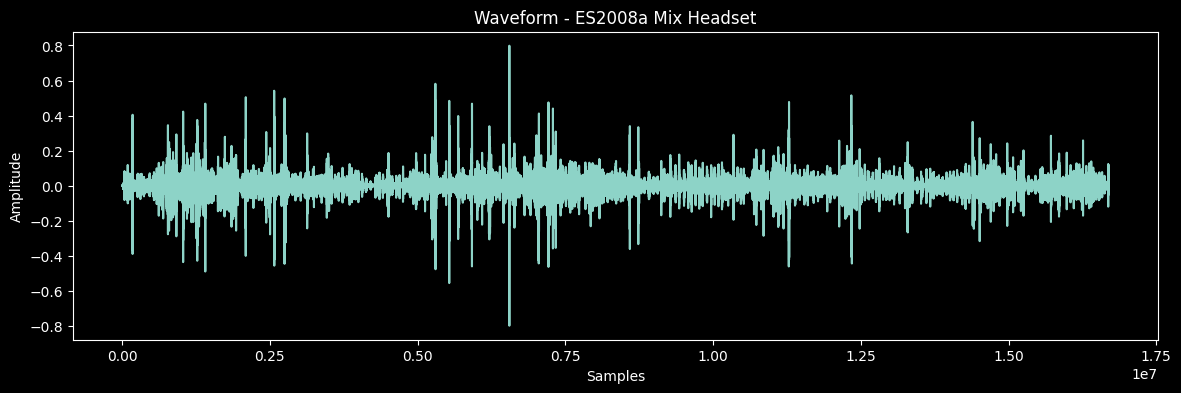

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(y)
plt.title("Waveform - ES2008a Mix Headset")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

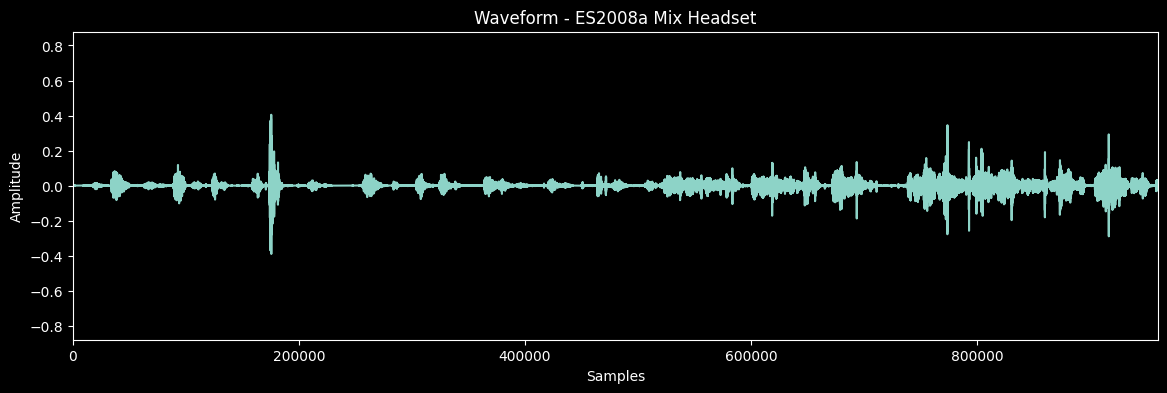

In [10]:
plt.figure(figsize=(14,4))
plt.plot(y)
plt.title("Waveform - ES2008a Mix Headset")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.xlim(0, sr * 60)  
plt.show()

From the above graph we can see the amplitude variation with time 
1. we can see clear burst in the high amplitude and variable internsity across speakers.


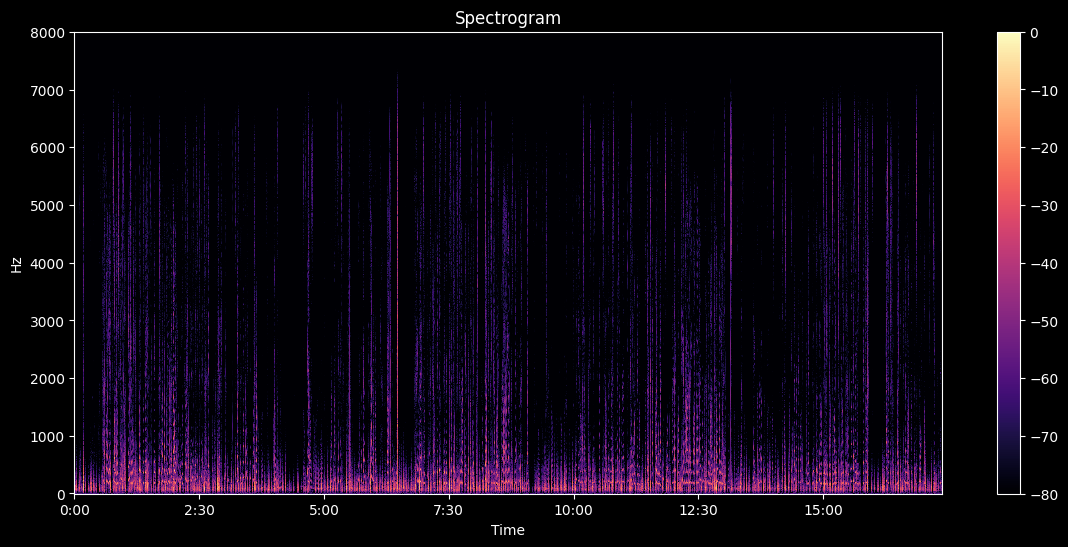

In [4]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(abs(D), ref=np.max)

plt.figure(figsize=(14,6))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram")
plt.show()

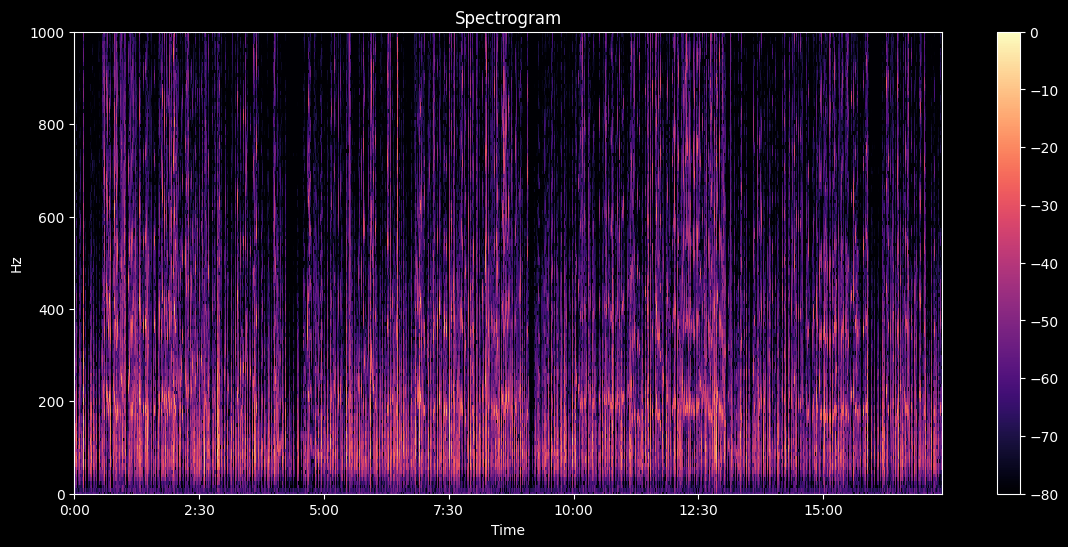

In [6]:
plt.figure(figsize=(14,6))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram")
plt.ylim(0, 1000)  
plt.show()

From above graphs we can see we have some peak and mostly except the begining and ending we dont see much silence we cant conculde that until we clean the data. 

so far we can conlude the frequency of the audio is within the human range but some energy burst are there we can filter it out

from the second graph we can see most of the frequency highly dence in 0-200 which means the noise in the background.

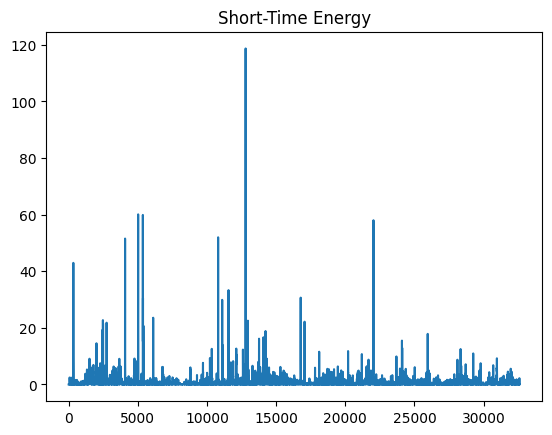

In [13]:
frame_length = 2048
hop_length = 512

energy = np.array([
    sum(abs(y[i:i+frame_length]**2))
    for i in range(0, len(y), hop_length)
])

plt.plot(energy)
plt.title("Short-Time Energy")
plt.show()

The meeting contains alternating silence and speech. Overlapping speech is there two people talking at the same time. the intensity varies but mostly lies between 0-5 db which might be noise are silent talk.

In [12]:
signal_power = np.mean(y**2)

sorted_energy = np.sort(energy)
noise_floor = np.mean(sorted_energy[:int(0.05*len(sorted_energy))])

snr = 10 * np.log10(signal_power / noise_floor)
print("Estimated SNR:", snr)

Estimated SNR: 6.825151


b. Why this data is best option for this project?

The AMI Meeting Corpus (ES2008a) is an appropriate dataset for this study because:

It contains multi-speaker team interaction

It represents realistic indoor acoustic conditions

It includes overlapping speech and natural turn-taking

It is widely used in speech and meeting analysis research

It provides structured metadata and public availability
